In [182]:
import pandas as pd
import json
from pathlib import Path
import requests
import os
import glob

In [185]:
Merge_Attractions_df = pd.read_csv("./merged_tat_attractions.csv")

In [186]:
Merge_Attractions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4325 entries, 0 to 4324
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   placeId               4325 non-null   object 
 1   place_name_th         4324 non-null   object 
 2   introduction_th       2546 non-null   object 
 3   category_name         4325 non-null   object 
 4   categoryId            4325 non-null   int64  
 5   latitude              4313 non-null   float64
 6   longitude             4313 non-null   float64
 7   postcode              4215 non-null   float64
 8   thumbnail_url         3601 non-null   object 
 9   tags                  857 non-null    object 
 10  province_Id           4325 non-null   int64  
 11  province_name_th      4325 non-null   object 
 12  district_Id           4317 non-null   float64
 13  district_name_th      4317 non-null   object 
 14  sub_district_Id       4217 non-null   float64
 15  sub_district_name_th 

In [65]:
len(Merge_Attractions_df)

4325

In [5]:
all_tripadvisor_attractions_locations = pd.read_csv("data/tripadvisor_locations_avaiable.csv")

In [6]:
all_tripadvisor_attractions_locations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1907 entries, 0 to 1906
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0.1  1907 non-null   int64 
 1   Unnamed: 0    1907 non-null   int64 
 2   place_id      1907 non-null   object
 3   location_id   1907 non-null   int64 
 4   name          1907 non-null   object
 5   state         1149 non-null   object
 6   country       1907 non-null   object
 7   postalcode    1315 non-null   object
dtypes: int64(3), object(5)
memory usage: 119.3+ KB


In [7]:
all_tripadvisor_attractions_locations = all_tripadvisor_attractions_locations.drop(
    columns=["Unnamed: 0.1", "Unnamed: 0"], errors="ignore"
)

In [8]:
all_tripadvisor_attractions_locations

,place_id,location_id,name,state,country,postalcode
0,P03003665,456633,House of Opium,57150.0,Thailand,57150.0
1,P03003665,23933132,Opium Bar,NaN,Thailand,10100.0
2,P03003590,7099963,Wat Phra That Doi Saket,50220.0,Thailand,50220.0
3,P03002324,1390125,Mae Ping River Cruise,50100.0,Thailand,50100.0
4,P03002324,547675,Pai River,NaN,Thailand,NaN
...,...,...,...,...,...,...
1902,P03017171,8647002,Nang Lae Nai Waterfall,NaN,Thailand,NaN
1903,P01000743,24105261,San Chao Rong Thong Market,NaN,Thailand,NaN
1904,P03018527,8328708,Cha's Bar,NaN,Thailand,10200.0
1905,P03018527,23208562,The Gundam Base Thailand Gallery,NaN,Thailand,10400.0


In [9]:
len(all_tripadvisor_attractions_locations)

1907

In [102]:
combined_details_df = pd.read_csv("data/combined_details.csv")

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from gensim.models import Word2Vec
import numpy as np
import re


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
import string

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


N_CLUSTER = 8

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/ittichaiboonyarakthunya/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ittichaiboonyarakthunya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/ittichaiboonyarakthunya/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [64]:
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [65]:
FINE_TUNED_DIR = '../../pretained_or_finetune-models'
REVIEWS_DATASET_DIR = '../../dataset'
UTILS_DIR = '../../utils'
NLTK_DATA_PATH = f"{FINE_TUNED_DIR}/nltk_data"

nltk.data.path.append(NLTK_DATA_PATH)

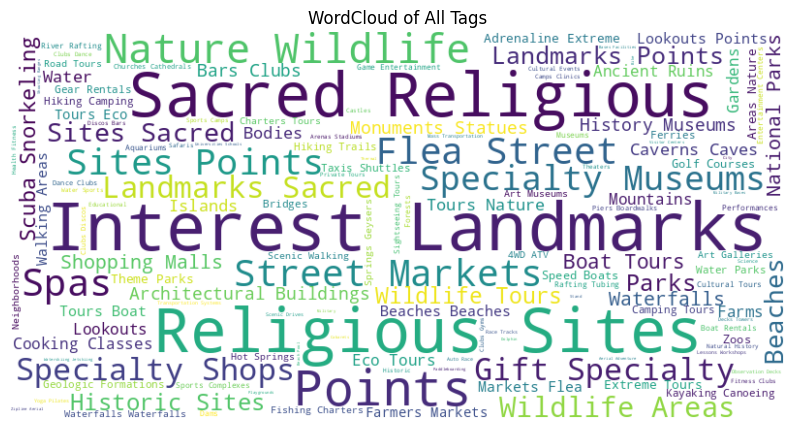

In [66]:
# รวมข้อความทั้งหมดจากคอลัมน์ 'tags'
all_text = " ".join(combined_details_df['tags'].fillna(''))

# สร้าง WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# แสดง WordCloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of All Tags")
plt.show()

## Experiment - 1 [TF-IDF + K-MEAN + LDA]

In [72]:
# ตรวจสอบและแทนค่าที่เป็น NaN ในคอลัมน์ 'tags'
combined_details_df['tags'] = combined_details_df['tags'].fillna('')
combined_details_df['tags'].replace("", "other", inplace=True)

# แปลงข้อความใน 'tags' ให้เป็นเมทริกซ์ TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(combined_details_df['tags'])

# สร้างโมเดล LDA เพื่อหา topics
lda_model = LatentDirichletAllocation(n_components=N_CLUSTER, random_state=42)  # กำหนด 5 topics
lda_model.fit(X)

# ดึง top keywords ในแต่ละ topic
def print_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

print_topics(lda_model, vectorizer.get_feature_names_out(), n_top_words=10)

# กำหนดกลุ่มให้แต่ละสถานที่
combined_details_df['topic'] = lda_model.transform(X).argmax(axis=1)



/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_5980/2620588952.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_details_df['tags'].replace("", "other", inplace=True)


Topic 0:
historic monuments statues buildings gardens sites architectural ruins ancient neighborhoods
Topic 1:
beaches shops gift areas specialty wildlife nature lookouts bodies water
Topic 2:
spas malls shopping farms walking courses golf scenic adrenaline extreme
Topic 3:
parks museums tours specialty national boat scuba snorkeling nature wildlife
Topic 4:
interest points landmarks of mountains sports lookouts aquariums complexes cultural
Topic 5:
sacred religious sites waterfalls ferries forests sightseeing workshops lessons schools
Topic 6:
islands clubs museums bars history caverns caves art galleries bridges
Topic 7:
markets street flea farmers geologic formations churches cathedrals tubing rafting


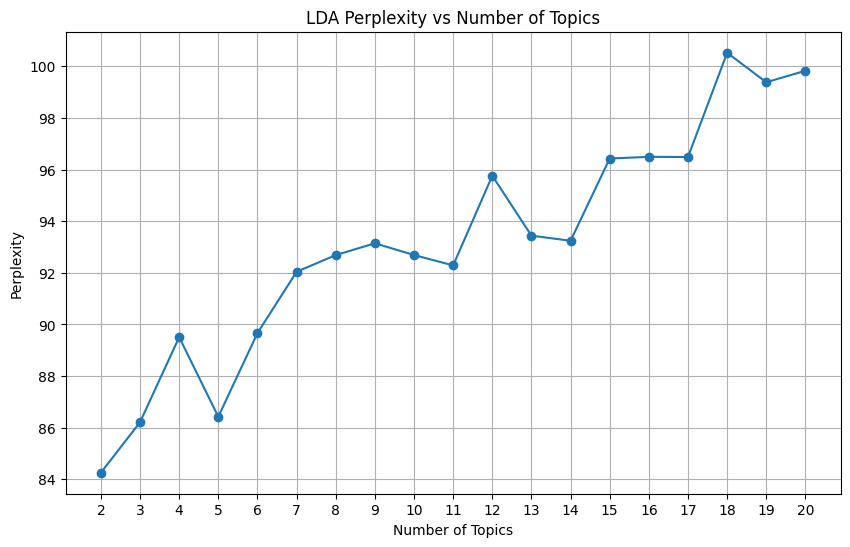

In [73]:
perplexities = []
topic_range = range(2, 21)  # กำหนดช่วงของจำนวนหัวข้อ (2 ถึง 20)

for n_topics in topic_range:
    lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=42)
    lda_model.fit(X)
    perplexities.append(lda_model.perplexity(X))

# การ Visualize ค่า Perplexity
plt.figure(figsize=(10, 6))
plt.plot(topic_range, perplexities, marker='o')
plt.title('LDA Perplexity vs Number of Topics')
plt.xlabel('Number of Topics')
plt.ylabel('Perplexity')
plt.xticks(topic_range)
plt.grid()
plt.show()

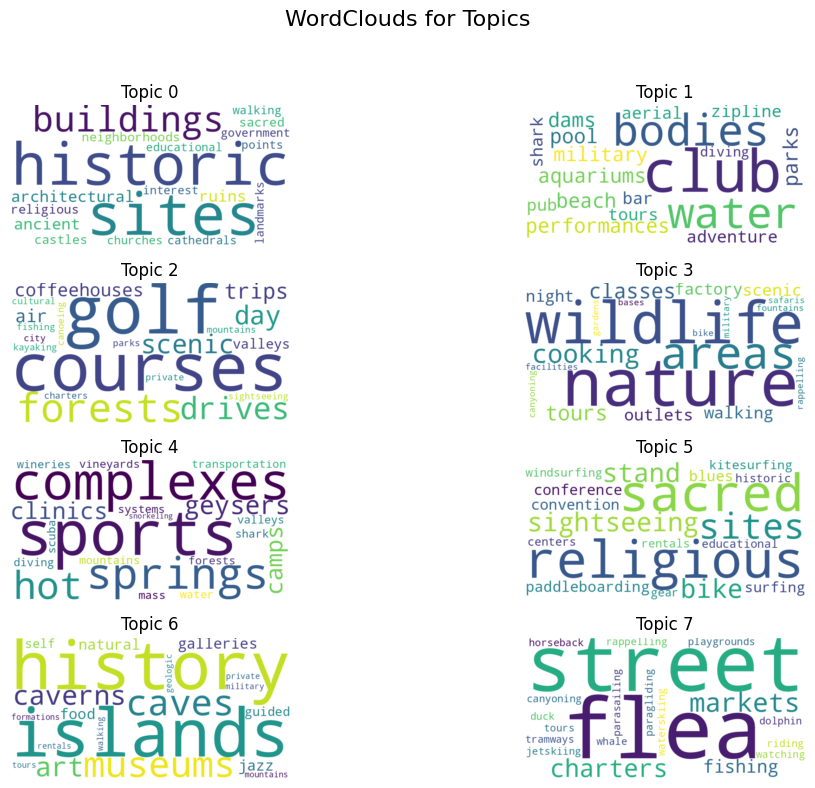

In [74]:
def get_topic_words(lda_model, feature_names, n_top_words=10):
    topic_words = []
    for topic_idx, topic in enumerate(lda_model.components_):
        words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topic_words.append(" ".join(words))
    return topic_words

# Generate topic words from LDA model
topic_words = get_topic_words(lda_model, vectorizer.get_feature_names_out(), n_top_words=20)

# Function to plot WordClouds in a 2x2 grid
def plot_wordclouds_in_grid(topic_words, n_rows=2, n_cols=2):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
    fig.suptitle("WordClouds for Topics", fontsize=16)
    
    for idx, words in enumerate(topic_words):
        if idx < n_rows * n_cols:
            row, col = divmod(idx, n_cols)
            wordcloud = WordCloud(width=800, height=400, background_color='white').generate(words)
            axes[row, col].imshow(wordcloud, interpolation='bilinear')
            axes[row, col].axis('off')
            axes[row, col].set_title(f"Topic {idx}", fontsize=12)
        else:
            axes[row, col].axis('off')  # Turn off any extra axes
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to leave space for title
    plt.show()

# Plot the WordClouds in a 2x2 grid
plot_wordclouds_in_grid(topic_words, n_rows=4, n_cols=2)

In [75]:
combined_details_df[['name', 'tags', 'topic']]

,name,tags,topic
0,House of Opium,"History Museums, Specialty Museums",6
1,Opium Bar,Bars & Clubs,6
2,Wat Phra That Doi Saket,Sacred & Religious Sites,5
3,Mae Ping River Cruise,Boat Tours,3
4,Pai River,Bodies of Water,1
...,...,...,...
1761,Chao Lao Beach,Beaches,1
1762,Chao Lao Fish Bridge,Bridges,6
1763,Wat Burapa Temple,"Sacred & Religious Sites, Architectural Buildings",0
1764,Kung Wiman Beach,Beaches,1


In [77]:
def advanced_clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^a-z\s]', '', text)  # Remove special characters
    text = re.sub(r'\b(u|ur|b4)\b', 'you', text)  # Replace common abbreviations
    words = word_tokenize(text)
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    words = [word for word in words if word not in string.punctuation]
    return ' '.join(words)

In [ ]:
combined_details_df = combined_details_df['tags'].replace("", "Other", inplace=True)

In [78]:
cleaned_details_df = combined_details_df['tags'].apply(advanced_clean_text)

cleaned_details_df

0                    history museum specialty museum
1                                           bar club
2                              sacred religious site
3                                          boat tour
4                                         body water
                            ...                     
1761                                           beach
1762                                          bridge
1763    sacred religious site architectural building
1764                                           beach
1765                                         lookout
Name: tags, Length: 1766, dtype: object

In [79]:
# === Import Section ===
# Word embedding and clustering libraries
from gensim.models import Word2Vec
from sklearn.cluster import KMeans

# Data manipulation libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt

# === Implementation ===

# Step 1: Train Word2Vec Model
# Tokenize sentences from your dataset
sentences = cleaned_details_df.apply(str.split).tolist()  # Tokenized sentences


In [80]:
sentences

[['history', 'museum', 'specialty', 'museum'],
 ['bar', 'club'],
 ['sacred', 'religious', 'site'],
 ['boat', 'tour'],
 ['body', 'water'],
 ['point', 'interest', 'landmark', 'lookout'],
 ['garden'],
 ['point', 'interest', 'landmark'],
 ['sightseeing', 'tour'],
 ['hot', 'spring', 'geyser'],
 ['national', 'park', 'park'],
 ['flea', 'street', 'market'],
 ['shopping', 'mall'],
 ['specialty', 'museum'],
 ['historic', 'site'],
 ['historic', 'site', 'ancient', 'ruin'],
 ['zoo'],
 ['point', 'interest', 'landmark'],
 ['performance'],
 ['sacred', 'religious', 'site'],
 ['sacred', 'religious', 'site'],
 ['sacred', 'religious', 'site'],
 ['monument', 'statue'],
 ['geologic', 'formation'],
 ['specialty', 'museum'],
 ['architectural', 'building'],
 ['point', 'interest', 'landmark', 'sacred', 'religious', 'site'],
 ['ancient', 'ruin'],
 ['point', 'interest', 'landmark'],
 ['point', 'interest', 'landmark'],
 ['sacred', 'religious', 'site'],
 ['sacred', 'religious', 'site'],
 ['nature', 'wildlife', 'are

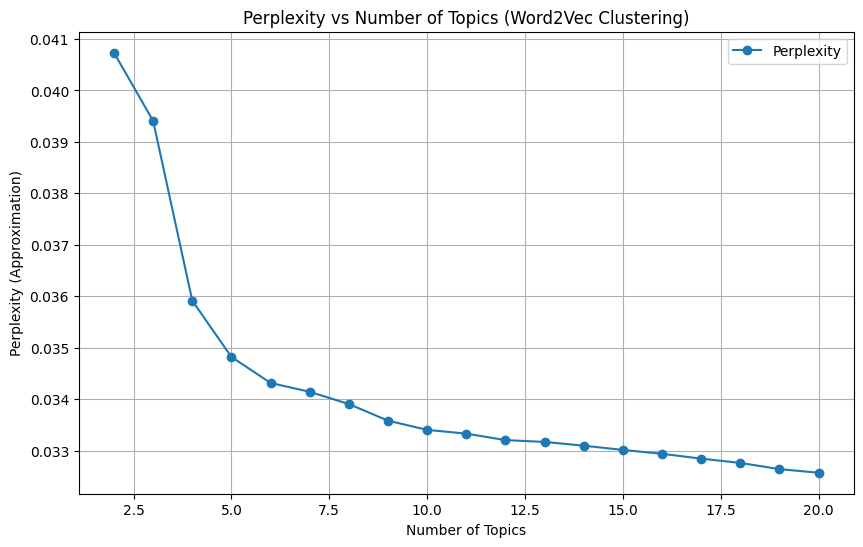

In [81]:

# Train Word2Vec model
word2vec = Word2Vec(sentences, vector_size=300, window=100, min_count=1, workers=4)

# Extract word embeddings and corresponding words
word_vectors = word2vec.wv.vectors  # Word embeddings (array of shape [vocab_size, vector_size])
vocab = word2vec.wv.index_to_key  # List of words corresponding to the embeddings

# Step 2: Function to Cluster Words into Topics
def cluster_words(n_clusters):
    """
    Cluster word vectors using KMeans.
    :param n_clusters: Number of clusters/topics
    :return: KMeans model
    """
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(word_vectors)
    return kmeans

# Step 3: Compute Perplexity Approximation
def compute_perplexity(model, n_clusters):
    """
    Compute a perplexity-like score for the KMeans clustering.
    :param model: Fitted KMeans model
    :param n_clusters: Number of clusters/topics
    :return: Approximation of perplexity (lower is better)
    """
    distances = []
    for i, word in enumerate(vocab):
        word_vector = word_vectors[i]
        cluster_center = model.cluster_centers_[model.labels_[i]]
        distances.append(np.linalg.norm(word_vector - cluster_center))  # Euclidean distance

    avg_distance = np.mean(distances)  # Average distance as a perplexity approximation
    return avg_distance

# Step 4: Evaluate Perplexity for Multiple Numbers of Topics
n_topics_list = range(2, 21)  # Define the range of topic numbers to test
perplexity_scores = []

# Iterate over different numbers of topics
for n_topics in n_topics_list:
    kmeans_model = cluster_words(n_clusters=n_topics)
    perplexity = compute_perplexity(kmeans_model, n_clusters=n_topics)
    perplexity_scores.append(perplexity)

# Step 5: Plot Perplexity vs. Number of Topics
plt.figure(figsize=(10, 6))
plt.plot(n_topics_list, perplexity_scores, marker='o', label="Perplexity")
plt.xlabel('Number of Topics')
plt.ylabel('Perplexity (Approximation)')
plt.title('Perplexity vs Number of Topics (Word2Vec Clustering)')
plt.grid()
plt.legend()
plt.show()


In [82]:
from sklearn.cluster import KMeans
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Step 1: Cluster Words Using KMeans
def cluster_words(n_clusters, word_vectors):
    """
    Cluster word vectors using KMeans.
    :param n_clusters: Number of clusters/topics
    :param word_vectors: Word embeddings from Word2Vec
    :return: Fitted KMeans model
    """
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(word_vectors)
    return kmeans

# Step 2: Generate Word Clouds for Each Cluster
def generate_word_clouds(model, vocab, output_dir):
    """
    Generate and save word clouds for each cluster.
    :param model: Fitted KMeans model
    :param vocab: Vocabulary corresponding to the word vectors
    :param output_dir: Directory to save the word cloud images
    """
    for cluster_idx in range(model.n_clusters):
        # Aggregate words belonging to the current cluster
        cluster_words = [vocab[i] for i in range(len(vocab)) if model.labels_[i] == cluster_idx]
        cluster_word_str = " ".join(cluster_words)
        
        print(f"\nCluster {cluster_idx}:")
        print(", ".join(cluster_words[:10]))

        # Generate Word Cloud
        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color="white",
            colormap="viridis"
        ).generate(cluster_word_str)

        # Save Word Cloud Image
        # output_path = f"{output_dir}/word_cloud_cluster_{cluster_idx}.png"
        # wordcloud.to_file(output_path)

        # Display Word Cloud
        # plt.figure(figsize=(10, 6))
        # plt.imshow(wordcloud, interpolation="bilinear")
        # plt.axis("off")
        # plt.title(f"Word Cloud for Cluster {cluster_idx}")
        # plt.show()


In [83]:
from sklearn.metrics.pairwise import cosine_similarity
cos_sim_matrix = cosine_similarity(word2vec.wv.vectors)

In [84]:
kmeans_model = cluster_words(n_clusters=20, word_vectors=word2vec.wv.vectors)


In [86]:
def compute_perplexity_cosine(kmeans_model, word_vectors):
    """
    Compute perplexity for KMeans clustering using cosine similarity on word embeddings.
    :param kmeans_model: Fitted KMeans model on word embeddings
    :param word_vectors: Word2Vec embeddings
    :return: Perplexity approximation (lower is better)
    """
    labels = kmeans_model.labels_
    cluster_centers = kmeans_model.cluster_centers_  # Cluster centers in the same space as word embeddings

    distances = []
    for i, label in enumerate(labels):
        word_vector = word_vectors[i]
        cluster_center = cluster_centers[label]
        
        # Cosine similarity between word vector and cluster center
        cos_sim = cosine_similarity(word_vector.reshape(1, -1), cluster_center.reshape(1, -1))[0][0]
        
        # Convert cosine similarity to distance
        cos_distance = 1 - cos_sim
        distances.append(cos_distance)

    # Average distance as perplexity approximation
    return np.mean(distances)

Clustering with 2 topics...
Clustering with 3 topics...
Clustering with 4 topics...
Clustering with 5 topics...
Clustering with 6 topics...
Clustering with 7 topics...
Clustering with 8 topics...
Clustering with 9 topics...
Clustering with 10 topics...
Clustering with 11 topics...
Clustering with 12 topics...
Clustering with 13 topics...
Clustering with 14 topics...
Clustering with 15 topics...
Clustering with 16 topics...
Clustering with 17 topics...
Clustering with 18 topics...
Clustering with 19 topics...
Clustering with 20 topics...
Clustering with 21 topics...
Clustering with 22 topics...
Clustering with 23 topics...
Clustering with 24 topics...
Clustering with 25 topics...
Clustering with 26 topics...
Clustering with 27 topics...
Clustering with 28 topics...
Clustering with 29 topics...
Clustering with 30 topics...
Clustering with 31 topics...
Clustering with 32 topics...
Clustering with 33 topics...
Clustering with 34 topics...
Clustering with 35 topics...
Clustering with 36 top

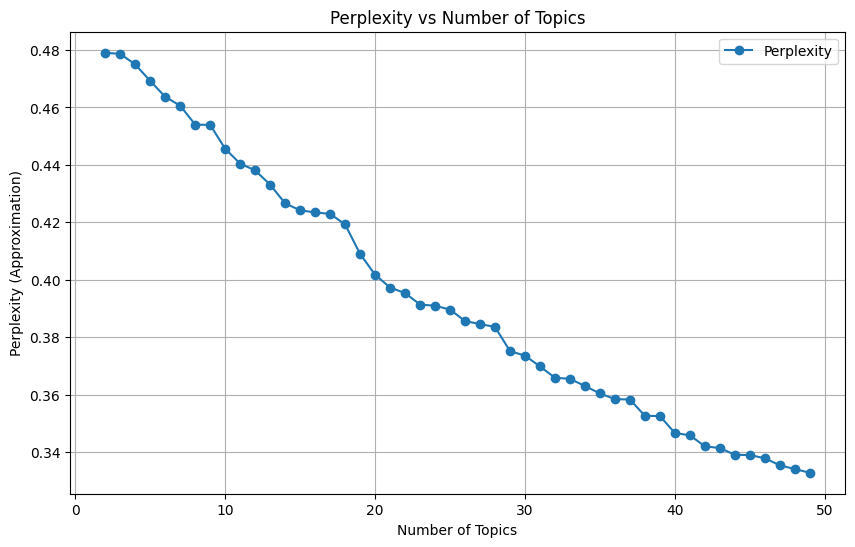

In [101]:
n_topics_range = range(2, 50)  # From 2 to 20 clusters
perplexity_scores = []

# Calculate perplexity for each number of clusters
for n_topics in n_topics_range:
    print(f"Clustering with {n_topics} topics...")
    kmeans_model = cluster_words(n_clusters=n_topics, word_vectors=word_vectors)
    perplexity = compute_perplexity_cosine(kmeans_model, word_vectors)
    perplexity_scores.append(perplexity)

# Plot perplexity vs. number of topics
plt.figure(figsize=(10, 6))
plt.plot(n_topics_range, perplexity_scores, marker='o', label='Perplexity')
plt.xlabel('Number of Topics')
plt.ylabel('Perplexity (Approximation)')
plt.title('Perplexity vs Number of Topics')
plt.grid()
plt.legend()
plt.show()

In [100]:
kmeans_model = cluster_words(n_clusters=20, word_vectors=word_vectors)
perplexity = compute_perplexity_cosine(kmeans_model, word2vec.wv.vectors)
print(f"Perplexity (approximation): {perplexity}")

Perplexity (approximation): 0.40177417411045596


In [94]:
word2vec.wv.index_to_key

['landmark',
 'interest',
 'point',
 'site',
 'sacred',
 'religious',
 'tour',
 'specialty',
 'museum',
 'wildlife',
 'nature',
 'park',
 'market',
 'spa',
 'flea',
 'street',
 'beach',
 'area',
 'shop',
 'gift',
 'boat',
 'club',
 'historic',
 'waterfall',
 'water',
 'snorkeling',
 'scuba',
 'lookout',
 'bar',
 'building',
 'national',
 'mall',
 'shopping',
 'architectural',
 'statue',
 'monument',
 'history',
 'body',
 'island',
 'cave',
 'cavern',
 'farm',
 'sport',
 'hiking',
 'ruin',
 'ancient',
 'eco',
 'rental',
 'art',
 'cooking',
 'class',
 'garden',
 'mountain',
 'walking',
 'farmer',
 'scenic',
 'theme',
 'cultural',
 'center',
 'extreme',
 'adrenaline',
 'course',
 'zoo',
 'golf',
 'trail',
 'speed',
 'bridge',
 'canoeing',
 'ferry',
 'formation',
 'kayaking',
 'geologic',
 'camping',
 'shuttle',
 'taxi',
 'gear',
 'game',
 'spring',
 'geyser',
 'complex',
 'charter',
 'neighborhood',
 'gallery',
 'fishing',
 'offroad',
 'atv',
 'wd',
 'hot',
 'aquarium',
 'performance',
 '

In [95]:
generate_word_clouds(kmeans_model, vocab=word2vec.wv.index_to_key, output_dir="./word_clouds")



Cluster 0:
point, sacred, religious, specialty, market, street, bar, history, cave, cavern

Cluster 1:
spa, beach, waterfall, island, farm, garden, mountain, theme, bridge, ferry

Cluster 2:
tour

Cluster 3:
interest, site, museum, nature, park, area, historic, water, sport, ruin

Cluster 4:
wildlife, club, building, architectural, hiking, rental, walking, camping, river, rafting

Cluster 5:
farmer, zoo, neighborhood, performance, theater, arena, event, pilate, workshop, yoga

Cluster 6:
boat, snorkeling, scuba, eco, extreme, adrenaline, speed, canoeing, kayaking, charter

Cluster 7:
landmark, flea, shop, gift, lookout, national, mall, shopping, statue, monument
